## Introduction

In this section, we study and implement a **Logarithmic Number System (LNS)** as an alternative to **Fixed-Point** and **Floating-Point** number systems. In this representation, numbers are stored as the logarithm of their absolute value, which is represented in fixed-point form, together with the sign of the number. This representation allows multiplication and division over real numbers to be performed using simple addition and subtraction, respectively. One of the main challenges of this system is addition and subtraction, which are usually approximated using techniques such as **LUT** or **Bit-Shift**.

Numbers in the LNS domain are represented as:

$$
\tilde{X} = (z_x, s_x, m_x)
$$

where $z_x$ indicates whether the number is zero, and $s_x$ represents the sign of the number. The value zero cannot be represented in LNS as $b^m$, so an extra bit is usually used to represent zero. Also, $m_x$ (the logarithm of the absolute value) is a two’s-complement fixed-point number with $W$ bits, of which $f$ bits are fractional.

In this section, we first implement software functions to convert numbers from the real domain to LNS and back, and then write functions for multiplication and addition (with different approximations). We also analyze results such as absolute and relative error in the logarithmic domain for different parameters, including the LNS bit width, the number of fractional bits, and the chosen base.

---


In [243]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(441)

class UnderflowError(Exception):
    pass


### 1.1 Conversion from Real Domain to LNS and Vice Versa
First, implement the necessary functions for converting numbers from the real domain to LNS and back. The LNS format should follow the description above. The base of the logarithm, bit length, and number of fractional bits must be given as inputs to these functions together with the number, so that the conversion is performed correctly.

To verify these functions, by setting the base to 2 and the bit width to 6 (3 bits for the fractional part), first determine the range of positive real numbers that can be represented by this LNS system. Then, in a table, report the LNS representation of the following numbers, their corresponding values in the real domain after converting back from logarithmic representation, and the absolute and relative errors in the real domain. Finally, analyze the results.

$$
\text{Test numbers} = \{0.0, 1.0, 1.5, 0.25, -2.0, 12.0, 15, -7.5, 0.001\}
$$
---


In [244]:

class LNSNum:
    def __init__(self, b=2, W=8, f=4, z=0, s=0, m=0):
        
        if b <= 0 or b == 1:
            raise ValueError("base must be positive and not equal to 1")

        self.b = b   # logarithm base
        self.W = W   # width - precission
        self.f = f   # fraction point position
        self.z = z   # zero flag
        self.s = s   # sign bit
        self.m = m   # log magnitude
    
    def __repr__(self):
        return f"LNS(z={self.z}, s={self.s}, m={self.m:^5})"


def to_lns(x, base=2, W=8, f=4) -> LNSNum:
          
    z = 0        
    s = 0        
    m = 0        
        
    if isinstance(x, (int, float, np.integer, np.floating)):
        if x == 0:
            z = 1
            return LNSNum(base, W, f, z, s, m)
        
        s = 1 if x < 0 else 0
        abs_x = abs(x)
        
        try:
            log_val = np.log(abs_x) / np.log(base)
            
            # check overflow/underflow base on traction point position
            scale = 2**f
            max_val = 2**(W - f - 1) - 2**(-f)
            min_val = -2**(W - f - 1)
        
            if log_val > max_val:
                raise OverflowError(f"Value {x} too large, return the max value")
                
            if log_val < min_val:
                raise UnderflowError(f"Value {x} too small, return zero")
                
                      
            # Quantize log_val to fixed-point format with f fractional bits
            # so m is stored in steps of 1/(2^f)
            m = int(np.round(log_val * scale)) / scale
        
        except OverflowError as e:
            m = max_val
            print(f"WARNING: {str(e)}")
            return LNSNum(base, W, f, z, s, m)
        
        except UnderflowError as e:
            z = 1
            print(f"WARNING: {str(e)}")           
            return LNSNum(base, W, f, z, s, m)
                    
    else :
        raise TypeError("input type sould be int or float")
    
    return LNSNum(base, W, f, z, s, m)

    
def to_real(lns_num : LNSNum) -> float:
    if lns_num.z:
        return 0
    sign = -1 if lns_num.s else 1
    return sign * (lns_num.b ** lns_num.m)


def mul_lns(a: LNSNum, b: LNSNum) -> LNSNum:
    if a.z or b.z:
        return LNSNum(a.b, a.W, a.f, 1, 0, 0)
    return LNSNum(a.b, a.W, a.f, 0, a.s ^ b.s, a.m + b.m)


In [245]:
print(f"Basis: {base}, Width: {W}, Fraction bits: {f}")

min_val = base ** (-2**(W - f - 1))
max_val = base ** (2**(W - f - 1) - 2**(-f))
print(f"Representable magnitude range: [{min_val:.4f}, {max_val:.4f}]")


Basis: 2, Width: 5, Fraction bits: 4
Representable magnitude range: [0.5000, 1.9152]


In [246]:
test_numbers = [0.0, 1.0, 1.5, 0.25, -2.0, 12.0, 15, -7.5, 0.001]
base, W, f = 2, 6, 3

print("\nNumber\tLNS Representation\t\tReconstructed\t\tError\t\tError (%)")

for num in test_numbers:
    lns = to_lns(num, base, W, f)
    real = to_real(lns)
    error = abs(num - real)
    rel_error = (error / abs(num)) * 100 if num != 0 else 0

    print(f"{num}\t{lns}\t\t{real:.4f}\t\t\t{error:.4f}\t\t{rel_error:.4f}")



Number	LNS Representation		Reconstructed		Error		Error (%)
0.0	LNS(z=1, s=0, m=  0  )		0.0000			0.0000		0.0000
1.0	LNS(z=0, s=0, m= 0.0 )		1.0000			0.0000		0.0000
1.5	LNS(z=0, s=0, m=0.625)		1.5422			0.0422		2.8141
0.25	LNS(z=0, s=0, m=-2.0 )		0.2500			0.0000		0.0000
-2.0	LNS(z=0, s=1, m= 1.0 )		-2.0000			0.0000		0.0000
12.0	LNS(z=0, s=0, m=3.625)		12.3377			0.3377		2.8141
15	LNS(z=0, s=0, m=3.875)		14.6721			0.3279		2.1862
-7.5	LNS(z=0, s=1, m=2.875)		-7.3360			0.1640		2.1862
0.001	LNS(z=1, s=0, m=  0  )		0.0000			0.0010		100.0000



---

### 1.2 Error Analysis in Number Conversion
In this section, we aim to examine more closely the error caused by converting numbers from the real domain to the logarithmic domain, and study the effect of parameters such as bit width and base on this error.

For this purpose, for each of the following parameter sets, determine the range of positive real numbers that can be represented by the corresponding LNS system. Then select a sufficient number of numbers uniformly across this range and plot the absolute and relative errors in separate graphs. Also report the average of these errors.

Then, by comparing the representable range of each of the following 4 parameter sets, the chosen base, the number of bits used ($W$), and the average relative errors, analyze the results and explain the observed tradeoffs.

$$
(\text{base}, W, f) = \{(\sqrt{2}, 8, 4), (2, 7, 4), (4, 6, 4), (16, 5, 4)\}
$$

---


In [247]:

parameters_set = [
    (np.sqrt(2), 8, 4),
    (2, 7, 4),
    (4, 6, 4),
    (16, 5, 4)
]

results = {}

for base, W, f in parameters_set:
    
    print(f"\nParameters: base={base:.3f}, W={W}, f={f}")
    print(f"Range: [{min_val:.6f}, {max_val:.6f}]")
    print("="*80)


    min_val = base ** (-2**(W - f - 1))
    max_val = base ** (2**(W - f - 1) - 2**(-f))

    num_samples = 1000
    real_samples = np.random.uniform(min_val, max_val, num_samples)

    errors = []
    rel_errors = []

    real_samples.sort()
    
    
    print(f"{'Number':>12}  {'LNS Representation':>25}  {'Reconstructed':>14}  {'Error':>12}  {'Error (%)':>12}")
    print("="*80)

    for x in real_samples:
        lns = to_lns(x, base, W, f)
        real = to_real(lns)

        error = abs(x - real)
        rel_error = (error / abs(x)) * 100 if x != 0 else 0

        errors.append(error)
        rel_errors.append(rel_error)

        print(f"{x:12.4f}  {str(lns):>25}  {real:14.4f}  {error:12.6f}  {rel_error:12.6f}")

    mean_error = np.mean(errors)
    mean_rel_error = np.mean(rel_errors)

    results[(base, W, f)] = {
        'samples': real_samples,
        'errors': errors,
        'rel_errors': rel_errors,
        'mean_error': mean_error,
        'mean_rel_error': mean_rel_error,
        'range': (min_val, max_val)
    }

    print(f"Mean Error: {mean_error:.6f}")
    print(f"Mean Relative Error: {mean_rel_error:.6f}%")



Parameters: base=1.414, W=8, f=4
Range: [0.500000, 1.915207]
      Number         LNS Representation   Reconstructed         Error     Error (%)
      0.0793   LNS(z=0, s=0, m=-7.3125)          0.0793      0.000028      0.035143
      0.1234   LNS(z=0, s=0, m=-6.0625)          0.1223      0.001050      0.850724
      0.1523   LNS(z=0, s=0, m=-5.4375)          0.1519      0.000379      0.248856
      0.1556    LNS(z=0, s=0, m=-5.375)          0.1552      0.000368      0.236325
      0.1559    LNS(z=0, s=0, m=-5.375)          0.1552      0.000714      0.457776
      0.1827    LNS(z=0, s=0, m=-4.875)          0.1846      0.001940      1.062004
      0.1986   LNS(z=0, s=0, m=-4.6875)          0.1970      0.001561      0.786396
      0.2108     LNS(z=0, s=0, m=-4.5 )          0.2102      0.000545      0.258673
      0.2639   LNS(z=0, s=0, m=-3.8125)          0.2668      0.002853      1.080934
      0.2810   LNS(z=0, s=0, m=-3.6875)          0.2786      0.002364      0.841462
      0.3066  

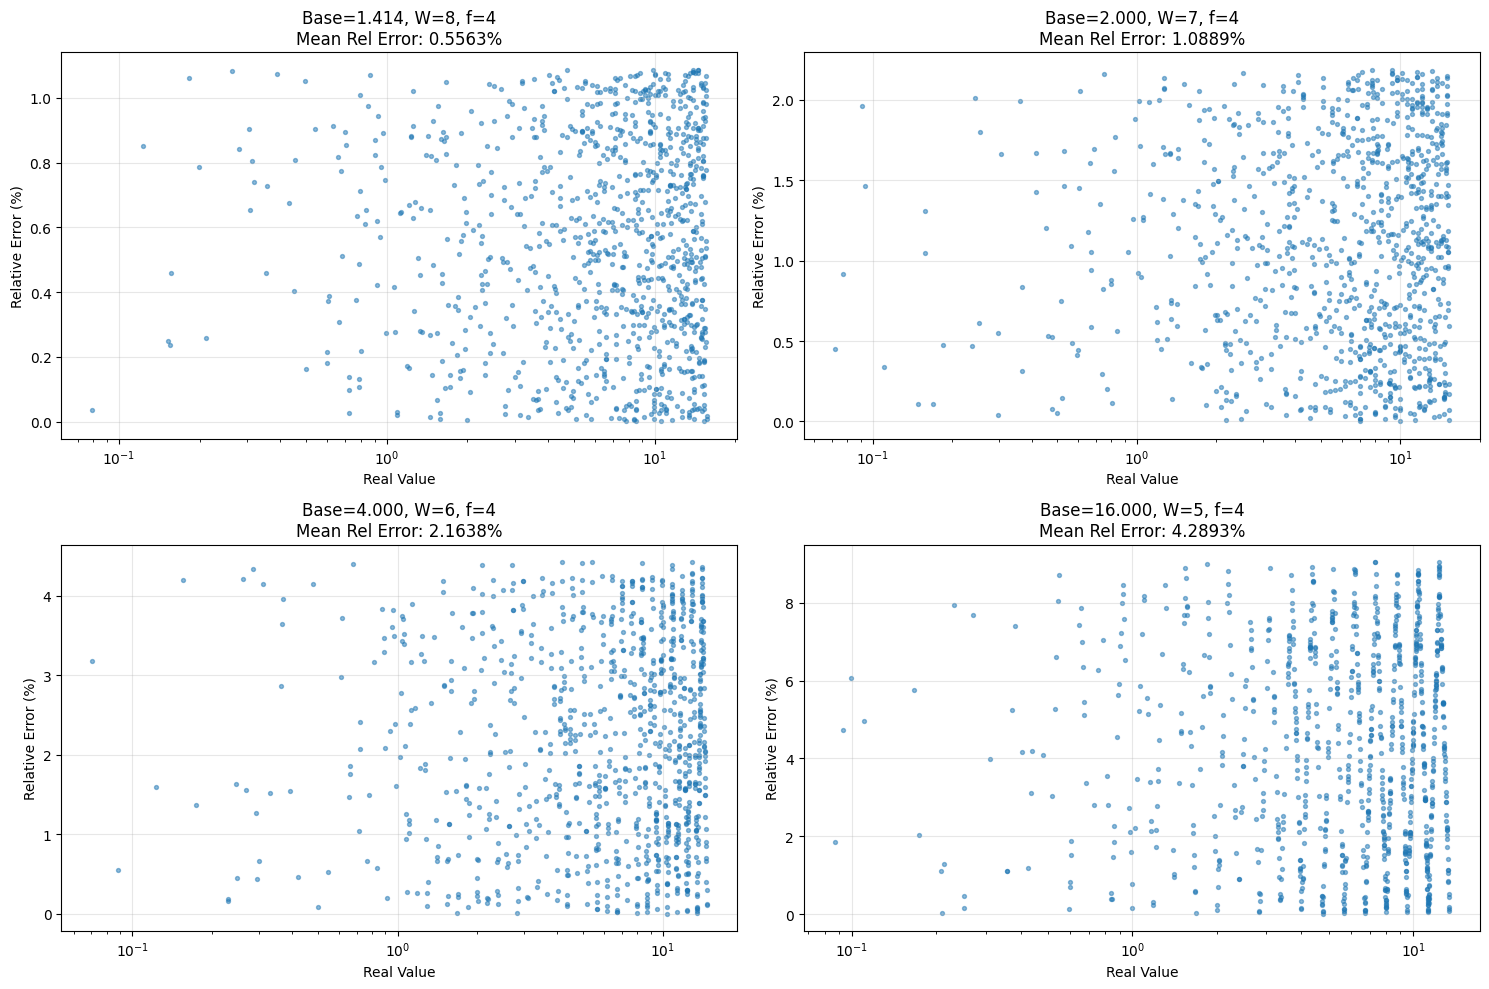

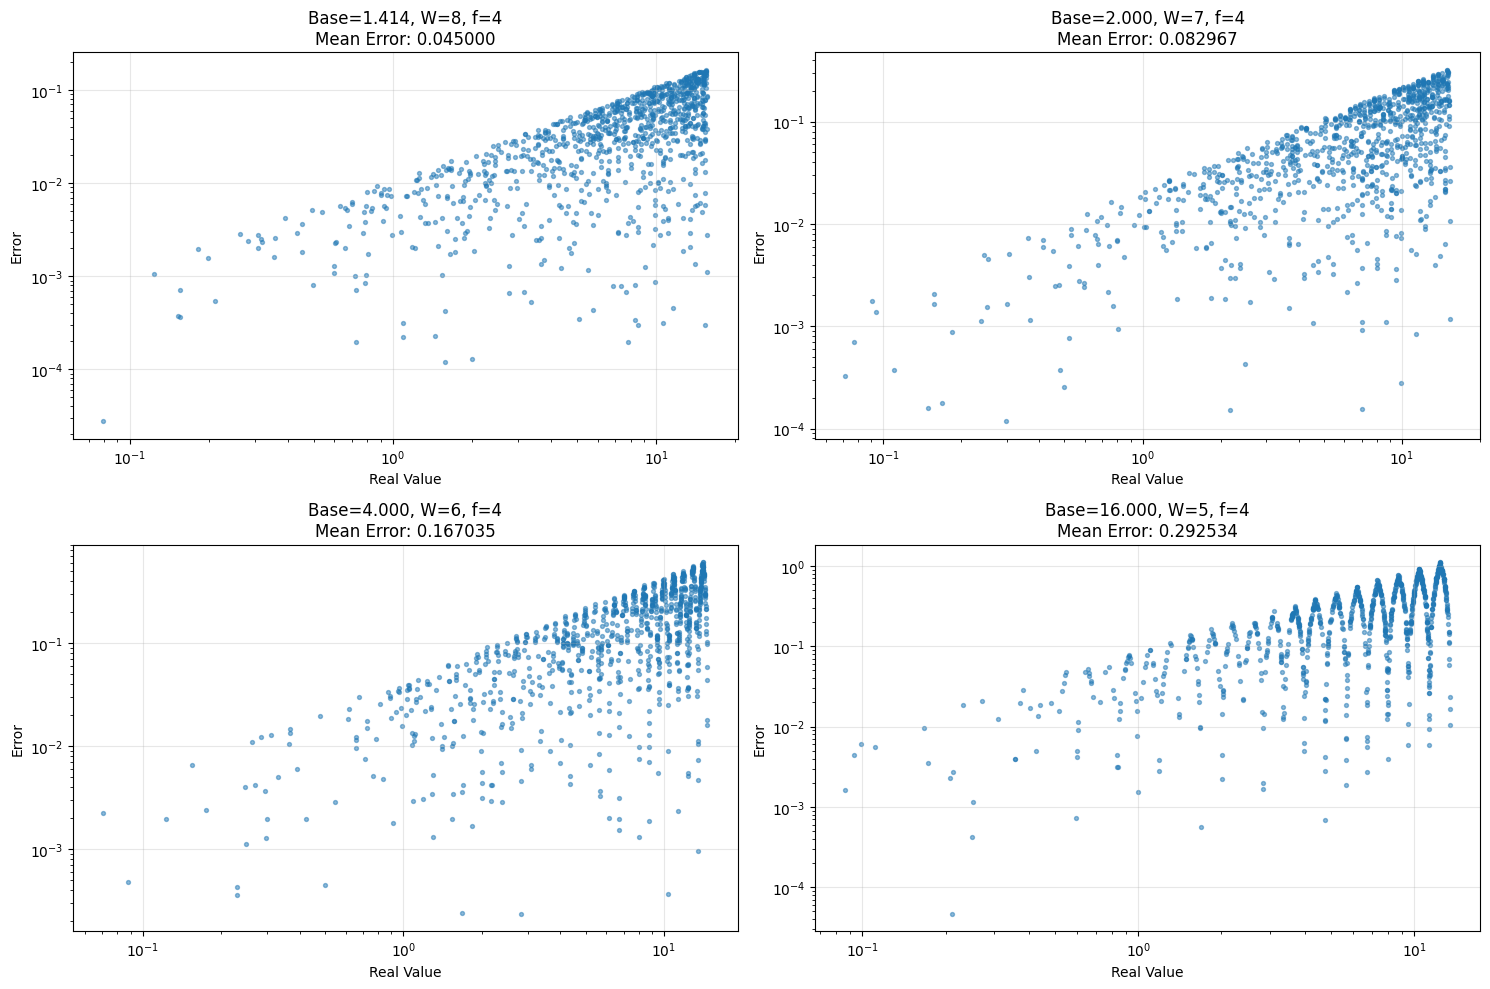

In [248]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ((base, W, f), data) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(data['samples'], data['rel_errors'], alpha=0.5, s=8)
    ax.set_xlabel('Real Value')
    ax.set_ylabel('Relative Error (%)')
    ax.set_title(f'Base={base:.3f}, W={W}, f={f}\nMean Rel Error: {data["mean_rel_error"]:.4f}%')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ((base, W, f), data) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(data['samples'], data['errors'], alpha=0.5, s=8)
    ax.set_xlabel('Real Value')
    ax.set_ylabel('Error')
    ax.set_title(f'Base={base:.3f}, W={W}, f={f}\nMean Error: {data['mean_error']:.6f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


As the base of the Logarithmic Number System (LNS) increases, the mean error grows significantly:
*   **Base $\sqrt{2}$:** Mean Error: 0.045
*   **Base 2:** Mean Error: 0.082 (approx. 2x increase)
*   **Base 4:** Mean Error: 0.167 (approx. 2x increase)
*   **Base 16:** Mean Error: 0.292 (approx. 1.7x increase)

Although the number of fractional bits is fixed ($f=4$), the quantization steps (the gap between representable numbers) in the real domain become wider as the base increases. These larger steps lead to higher rounding errors.

**Benefit (Cost Savings):** Increasing the base allows for covering the same dynamic range with fewer bits (reducing $W$ from 8 to 5). This translates to a ~37.5% saving in memory and bandwidth.

**Cost (Accuracy Loss):** This efficiency comes at the price of a severe loss in precision. In this experiment, the mean error increased by a factor of more than 6.

with increase the base, a distinct wave-like or sawtooth pattern is visible.
This pattern is a direct visual artifact of large quantization steps. 
When the gaps between representable numbers are large, 
the rounding error oscillates periodically between zero and a maximum value, 
creating this wave shape. For smaller bases, 
these steps are so fine that the error points form what appears to be a continuous band.


---

### 1.3 LNS Addition
In this section, we implement addition operations in the LNS domain. As shown in the figure below, the term

$$
\Delta^\pm = \log_2(1 \pm 2^{-|\;m_1 - m_2\;|})
$$

makes addition in this domain challenging. To address this issue, this term is approximated using LUT or Bit-Shift.

First, implement a function for addition in which the $\Delta$ term is computed exactly. Then, implement appropriate addition functions for each of the mentioned approximations. In the LUT approximation, you must precompute an array of $\pm\Delta$ values with a specified size and use those values during addition. In this section, the logarithm base, bit width, and number of fractional bits must also be given as inputs to these functions so that the operation is performed correctly.

$$
s\tilde{u}m =
\begin{cases}
\max(\tilde{n}_1, \tilde{n}_2) + \log_2(1 + 2^{-|\tilde{n}_1 - \tilde{n}_2|}), & \text{if } s_{n1} = s_{n2} \\
\max(\tilde{n}_1, \tilde{n}_2) + \log_2(1 - 2^{-|\tilde{n}_1 - \tilde{n}_2|}), & \text{if } s_{n1} \neq s_{n2}
\end{cases}
$$

To verify the functions, by setting the base to 2 and bit width to 8 (4 bits for the fractional part), for each of the following input pairs, report the result of addition using each of the 3 functions, as well as the relative errors of the two approximation methods with respect to the exact addition result, in a table.

For the LUT approximation, consider the number of precomputed $+\Delta$ and $-\Delta$ values to be 32.

$$
(a, b) = \{(2.5, 3), (-4.75, -9.2), (0.25, 2.25), (4.5, 4.45), (-10, -10.2), (-2, 0)\}
$$

---


In a general LNS system, the correction term depends on

$$
d = |m_1 - m_2| \in [0 , \infty)
$$

and in theory this is a continuous quantity.  
That is why many generic LUT implementations try to map a continuous $d$ into a finite table range such as:

$$
0 \le d \le 10
$$

because for large values of $d$,

$$
d > 10 \rightarrow 2^{-d} \approx 0 \rightarrow \log_2(1 \pm 2^{-d}) \approx 0
$$

So in a general-purpose design, people often need scaling, clamping, or heuristic index mapping.

In **our** implementation, the logarithmic value $m$ is already quantized.

That means $m$ is not continuous.  
It can only take discrete values separated by

$$
\text{step} = \frac{1}{2^f}
$$

So if $m_1$ and $m_2$ are both quantized, then their difference is also quantized and $d$ can only be one of these values:

$$
0,\ \frac{1}{2^f},\ \frac{2}{2^f},\ \frac{3}{2^f},\dots
$$

So LUT entry `i` corresponds exactly to one possible quantized value of $d$.

This makes indexing natural:

- `i = 0` corresponds to $d = 0$
- `i = 1` corresponds to $d = \frac{1}{2^f}$
- `i = 2` corresponds to $d = \frac{2}{2^f}$
- ...
- `i = 31` corresponds to $d = \frac{31}{2^f}$

So instead of mapping a continuous $d$ into the table approximately, we can use the quantized structure of our own LNS format.


In [249]:
b = 2
w = 8
f = 4

In [250]:
size = 160
step = 1 / (2**f)

delta_plus = []
delta_minus = []

for i in range(size):

    d = i * step

    delta_p = np.log2(1 + 2**(-d))

    if d == 0:
        delta_m = float("-inf")
    elif d >= 10:
        delta_m = 0
    else:
        delta_m = np.log2(1 - 2**(-d))

    delta_plus.append(delta_p)
    delta_minus.append(delta_m)

LUT = {
    "size": size,
    "plus": np.array(delta_plus),
    "minus": np.array(delta_minus)
}

In [251]:
def add_exact(a: LNSNum, b: LNSNum):

    if a.z:
        return b
    if b.z:
        return a

    max_m = max(a.m, b.m)
    diff = abs(a.m - b.m)
    
    if a.s == b.s:   
        if diff == 0:
            result_m = max_m + 1
        else:
            result_m = max_m + np.log2(1 + 2**(-diff))

        result_s = a.s
        return LNSNum(a.b, a.W, a.f, 0, result_s, result_m)

    else:
        # underflow nashe
        if abs(a.m - b.m) < 1e-10:
            return LNSNum(a.b, a.W, a.f, 1, 0, 0)


        arg = 1 - 2**(-diff)
        if arg <= 0:
            print("WARNING: LOG-Arg is negative. return zero.")
            return LNSNum(a.b, a.W, a.f, 1, 0, 0)

        delta = np.log2(arg)
        result_s = a.s if a.m > b.m else b.s

        return LNSNum(a.b, a.W, a.f, 0, result_s, max_m + delta)



In [252]:
def add_lut(a: LNSNum, b: LNSNum, lut):

    if a.z:
        return b
    if b.z:
        return a

    max_m = max(a.m, b.m)
    diff = abs(a.m - b.m)

    idx = int(round(diff * (2 ** a.f)))

    if a.s == b.s:
        result_s = a.s
    else:
        result_s = a.s if a.m > b.m else b.s

    if idx >= lut["size"]:
        delta = 0.0
    else:
        if a.s == b.s:
            delta = lut["plus"][idx]
        else:
            delta = lut["minus"][idx]
            
    if np.isinf(delta) or np.isnan(delta):
        return LNSNum(a.b, a.W, a.f, 1, 0, 0)

    final_m = max_m + delta
    
    return LNSNum(a.b, a.W, a.f, 0, result_s, final_m)


In [253]:
def add_shift(a, b):
    if a.z:
        return b
    if b.z:
        return a

    max_m = max(a.m, b.m)
    diff = abs(a.m - b.m)

    delta = 2 ** (-diff)
    
    if diff >= 32:
        delta = 0.0

    if a.s == b.s:
        result_m = max_m + delta
        result_s = a.s
    else:
        if a.m == b.m: 
            return LNSNum(a.b, a.W, a.f, 1, 0, 0)
            
        result_m = max_m - delta
        result_s = a.s if a.m > b.m else b.s

    return LNSNum(a.b, a.W, a.f, 0, result_s, result_m)


In [254]:
# I’m getting old dealing with Jupyter Notebook.
# It's driving me crazy

import builtins
max = builtins.max
min = builtins.min

In [255]:
test_pairs = [(2.5, 3), (-4.75, -9.2), (0.25, 2.25), (4.5, 4.45), (-10, -10.2), (-2, 0)]

print(f"{'Pair':<15}{'Expected':<12}{'Exact':<12}{'LUT':<12}{'Shift':<12}{'Err LUT %':<12}{'Err Shift %':<12}")

for a, b in test_pairs:
    lns_a = to_lns(a, 2, 8, 4)
    lns_b = to_lns(b, 2, 8, 4)

    exact_result = add_exact(lns_a, lns_b)
    exact_real = to_real(exact_result)

    lut_result = add_lut(lns_a, lns_b, LUT)
    lut_real = to_real(lut_result)

    shift_result = add_shift(lns_a, lns_b)
    shift_real = to_real(shift_result)

    expected = a + b

    if expected != 0:
        error_lut = abs(lut_real - expected) / abs(expected) * 100
        error_shift = abs(shift_real - expected) / abs(expected) * 100
    else:
        error_lut = 0 if lut_real == 0 else float('inf')
        error_shift = 0 if shift_real == 0 else float('inf')

    print(f"{str((a,b)):<15}{expected:<12.4f}{exact_real:<12.4f}{lut_real:<12.4f}{shift_real:<12.4f}{error_lut:<12.4f}{error_shift:<12.4f}")


Pair           Expected    Exact       LUT         Shift       Err LUT %   Err Shift % 
(2.5, 3)       5.5000      5.4374      5.4374      5.2905      1.1388      3.8096      
(-4.75, -9.2)  -13.9500    -13.8671    -13.8671    -13.0831    0.5940      6.2141      
(0.25, 2.25)   2.5000      2.5276      2.5276      2.4576      1.1031      1.6949      
(4.5, 4.45)    8.9500      8.9172      8.9172      8.8465      0.3666      1.1567      
(-10, -10.2)   -20.2000    -20.3096    -20.3096    -20.1485    0.5425      0.2548      
(-2, 0)        -2.0000     -2.0000     -2.0000     -2.0000     0.0000      0.0000      



---

### 1.4 Analysis of Addition
In this section, using the same parameters as in the previous part and by determining the range of representable positive real numbers, select 1000 random pairs of positive numbers in this range (for avoiding overflow, you may consider the random range to be half of the full range). Then compute the sum using all three functions for them, and calculate the average relative and absolute errors of each of the two approximations (LUT-based and Shift-based). Also plot the error curves versus $|m_a - m_b|$, and analyze the results.

Investigate how changing the LUT size (for example, reducing it from 32 to 16) affects the error of this method.

---

Mean relative error (LUT Size 160): 0.8131%
Mean relative error (Shift): 3.9343%


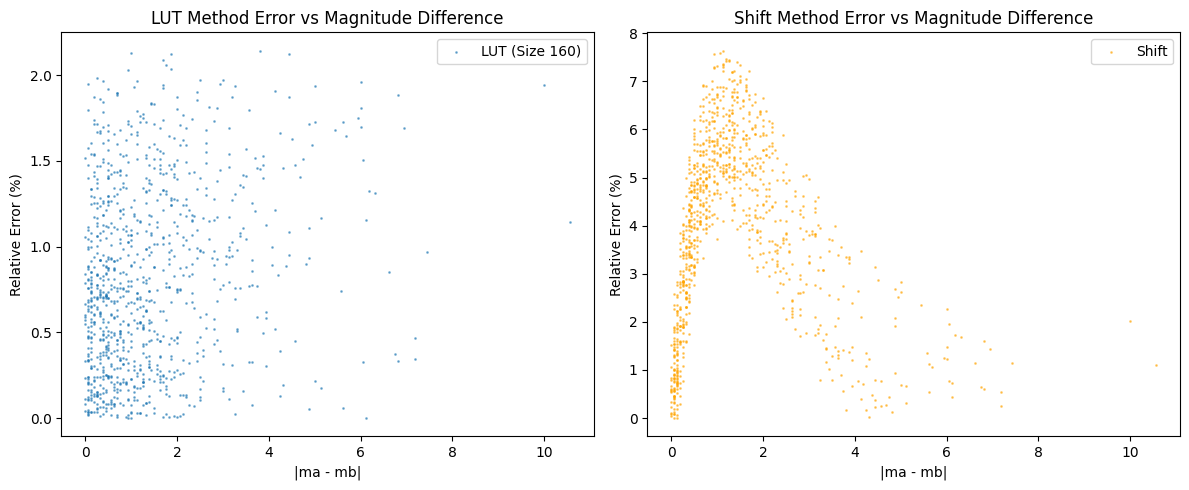

In [256]:
base = 2
w = 8
f = 4

min_val = base ** (-base**(w-f-1))
max_val = base ** (base**(w-f-1) - base**(-f))
test_range = max_val / base 

errors_lut = []
errors_shift = []
diff_values = []

import warnings
warnings.filterwarnings('ignore')
np.random.seed(441)

for _ in range(1000):
    val_a = np.random.uniform(min_val, test_range)
    val_b = np.random.uniform(min_val, test_range)
    
    lns_a = to_lns(val_a, base, w, f)
    lns_b = to_lns(val_b, base, w, f)
    
    real_sum = val_a + val_b
    
    lut_result = add_lut(lns_a, lns_b, LUT)
    lut_real = to_real(lut_result)
    
    shift_result = add_shift(lns_a, lns_b)
    shift_real = to_real(shift_result)
    
    err_lut = abs(lut_real - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    err_shift = abs(shift_real - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    
    errors_lut.append(err_lut)
    errors_shift.append(err_shift)
    diff_values.append(abs(lns_a.m - lns_b.m))

mean_err_lut = np.mean(errors_lut)
mean_err_shift = np.mean(errors_shift)

print(f"Mean relative error (LUT Size 160): {mean_err_lut:.4f}%")
print(f"Mean relative error (Shift): {mean_err_shift:.4f}%")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(diff_values, errors_lut, alpha=0.5, s=1, label='LUT (Size 160)')
plt.xlabel('|ma - mb|')
plt.ylabel('Relative Error (%)')
plt.title('LUT Method Error vs Magnitude Difference')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(diff_values, errors_shift, alpha=0.5, s=1, label='Shift', color='orange')
plt.xlabel('|ma - mb|')
plt.ylabel('Relative Error (%)')
plt.title('Shift Method Error vs Magnitude Difference')
plt.legend()

plt.tight_layout()
plt.show()


In [257]:
def generate_lut(size):
    delta_plus = []
    delta_minus = []

    for i in range(size):
        x = 0 if i == 0 else i / size * 10

        if x == 0:
            delta_p = 1.0
        else:
            delta_p = np.log2(1 + 2 ** (-x))

        if x == 0:
            delta_m = 0.0
        else:
            arg = 1 - 2 ** (-x)
            delta_m = np.log2(arg) if arg > 0 else float("-inf")

        delta_plus.append(delta_p)
        delta_minus.append(delta_m)

    return {"size": size, "plus": np.array(delta_plus), "minus": np.array(delta_minus)}


Mean relative error (LUT Size 160): 0.8131%
Mean relative error (LUT Size 32):  21.9013%
Mean relative error (LUT Size 16):  26.2797%
Mean relative error (Shift): 3.9343%


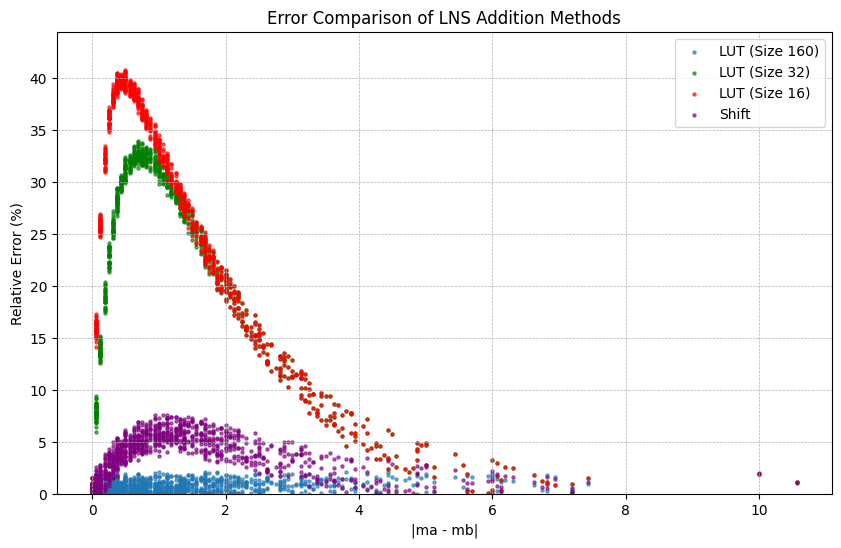

In [258]:
base = 2
w = 8
f = 4

LUT_32 = generate_lut(32)
LUT_16 = generate_lut(16)
LUT_160 = generate_lut(160)

min_val = base ** (-(2**(w - f - 1)))
max_val = base ** ((2**(w - f - 1)) - (base**(-f)))
test_range = max_val / base 

errors_lut_160, errors_lut_32, errors_lut_16, errors_shift = [], [], [], []
diff_values = []

np.random.seed(441)
num_tests = 1000

for _ in range(num_tests):
    val_a = np.random.uniform(min_val, test_range)
    val_b = np.random.uniform(min_val, test_range)
    
    lns_a = to_lns(val_a, base, w, f)
    lns_b = to_lns(val_b, base, w, f)
    
    real_sum = val_a + val_b
    
    lut_res_160 = add_lut(lns_a, lns_b, LUT_160)
    lut_real_160 = to_real(lut_res_160)
    err_160 = abs(lut_real_160 - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    
    lut_res_32 = add_lut(lns_a, lns_b, LUT_32)
    lut_real_32 = to_real(lut_res_32)
    err_32 = abs(lut_real_32 - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    
    lut_res_16 = add_lut(lns_a, lns_b, LUT_16)
    lut_real_16 = to_real(lut_res_16)
    err_16 = abs(lut_real_16 - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    
    shift_res = add_shift(lns_a, lns_b)
    shift_real = to_real(shift_res)
    err_shift = abs(shift_real - real_sum) / abs(real_sum) * 100 if real_sum != 0 else 0
    
    errors_lut_160.append(err_160)
    errors_lut_32.append(err_32)
    errors_lut_16.append(err_16)
    errors_shift.append(err_shift)
    diff_values.append(abs(lns_a.m - lns_b.m))

print(f"Mean relative error (LUT Size 160): {np.mean(errors_lut_160):.4f}%")
print(f"Mean relative error (LUT Size 32):  {np.mean(errors_lut_32):.4f}%")
print(f"Mean relative error (LUT Size 16):  {np.mean(errors_lut_16):.4f}%")
print(f"Mean relative error (Shift): {np.mean(errors_shift):.4f}%")


plt.figure(figsize=(10, 6))
plt.scatter(diff_values, errors_lut_160, alpha=0.6, s=5, label='LUT (Size 160)')
plt.scatter(diff_values, errors_lut_32, alpha=0.6, s=5, label='LUT (Size 32)', c='green')
plt.scatter(diff_values, errors_lut_16, alpha=0.6, s=5, label='LUT (Size 16)', c='red')
plt.scatter(diff_values, errors_shift, alpha=0.6, s=5, label='Shift', c='purple')

plt.xlabel('|ma - mb|')
plt.ylabel('Relative Error (%)')
plt.title('Error Comparison of LNS Addition Methods')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, np.percentile(errors_lut_16, 99) * 1.1)
plt.show()


In an LNS adder, adding two numbers is equivalent to multiplying the larger one by a correction factor $ (1 + 2^{-d}) $. As $ d $ grows, $ 2^{-d} $ becomes very small, so the sum gets closer to the larger number alone, meaning $ \delta \to 0 $.

LUT-160 covers a wide enough range of $ d $ values, so it captures the important nonlinear part of the logarithmic function accurately. As a result, its error stays very small and nearly constant.
  
LUT-32 and LUT-16 only cover limited ranges of $ d $. Once $ d $ exceeds their range, the implementation returns $ \delta = 0 $, effectively assuming the smaller number has no contribution. This creates very large errors, especially for moderate $ d $, where the correction is still important. For larger $ d $, both methods overlap because both reduce to the same approximation $ A+B \approx \max(A,B) $.

This method uses the approximation  
$$
\log_2(1+2^{-d}) \approx 2^{-d}
$$
Its error is higher than the large LUT, but much lower than the small LUTs in the critical region, because it approximates the correction smoothly instead of abruptly forcing it to zero.

If hardware resources allow, a large LUT gives the best accuracy. But if memory is limited, very small LUTs are actually a poor choice because of truncation error. In that case, the shift-based approximation is a safer and more reliable alternative.



---

### 1.5 NN Application
Now we want to observe the effect of using LNS in neural networks with a simple example.

By setting bit width to 8 (4 bits for the fractional part) and base to 2, randomly initialize a neural network layer whose input and filter both have dimensions $3 \times 7 \times 7$ (so that the output is a scalar). Use the range $[0, 4]$ for the input values and $[-4, 4]$ for the filter values.

Now compute the convolution once in the real domain, and once more by converting the inputs and weights to LNS representation, performing multiplication and addition in the LNS domain, and converting only the final result back to the real domain. The LNS-domain computations should be performed separately using each of the three addition functions, and the results should be compared with the expected value, with the error of each reported.

---

In [ ]:

X_real = np.random.uniform(0, 4, (3, 7, 7))
W_real = np.random.uniform(-4, 4, (3, 7, 7))

real_output = np.sum(X_real * W_real)
print(f"Real Output: {real_output:.4f}")

lut160 = generate_lut(160)
lut32  = generate_lut(32)

X_lns = [to_lns(x) for x in X_real.flatten()]
W_lns = [to_lns(w) for w in W_real.flatten()]

mul_results = [mul_lns(x, w) for x, w in zip(X_lns, W_lns)]

sum_lut160 = mul_results[0]
sum_lut32  = mul_results[0]
sum_shift  = mul_results[0]

for i in range(1, len(mul_results)):
    sum_lut160 = add_lut(sum_lut160, mul_results[i], lut160)
    sum_lut32  = add_lut(sum_lut32,  mul_results[i], lut32)
    sum_shift  = add_shift(sum_shift, mul_results[i])

out_lut160_real = to_real(sum_lut160)
out_lut32_real  = to_real(sum_lut32)
out_shift_real  = to_real(sum_shift)

def calc_error(exact, approx):
    return abs(exact - approx) / abs(exact) * 100

print("-" * 30)
print(f"LNS Output (LUT 160): {out_lut160_real:.4f} | Error: {calc_error(real_output, out_lut160_real):.2f}%")
print(f"LNS Output (LUT 32) : {out_lut32_real:.4f} | Error: {calc_error(real_output, out_lut32_real):.2f}%")
print(f"LNS Output (Shift)  : {out_shift_real:.4f} | Error: {calc_error(real_output, out_shift_real):.2f}%")


Real Output: 109.7918
------------------------------
LNS Output (LUT 160): 110.5241 | Error: 0.67%
LNS Output (LUT 32) : 27.9096 | Error: 74.58%
LNS Output (Shift)  : 94.2623 | Error: 14.14%
